# Hour 2 · Notebook 4. Comparative Evaluation: Linear Probing Three SSL Families

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/remote_sensing/04_comparative_evaluation.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026: *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 2.5. Closing Hour 2 (slides 47-49) · Table I

---

Notebooks 1-3 each trained a ViT-S/8 encoder with a different SSL mechanism: contrastive
(SimCLR), masking (MAE), and self-distillation (DINO), on the identical architecture and
token budget. This notebook asks the question that matters for a practitioner: **which
mechanism produced the more useful representation, and for what regime?**

<div class="alert alert-info">

**Linear probing protocol.** We freeze each pretrained encoder entirely and train only a
single linear layer (logistic regression) on top of a single global embedding per image,
using the labeled EuroSAT train split. Test accuracy on the held-out split then measures
representation quality directly. If the encoder is frozen, the only thing that can vary
between families is what the pretraining objective taught it to encode. This is the standard
protocol from the original SimCLR/MAE/DINO papers.

**How that global embedding is read out differs by family, and it has to.** Contrastive and
DINO both optimize the `[CLS]` token directly, so `[CLS]` is their natural readout. MAE never
supervises `[CLS]` at all (its loss lives entirely on the patch tokens), so probing MAE's
`[CLS]` reads a token that no gradient ever shaped. Mean-pooling the patch tokens is the
standard MAE readout (He et al., 2022), and that is what we use. See `POOL_BY_FAMILY` below.

</div>

In [1]:
## Standard libraries
import math
import os
import urllib.request

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.utils.data as data

## scikit-learn for the linear probe + confusion matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/remote_sensing/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "remote_sensing")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_rs.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_rs.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/remote_sensing/tutorial_rs.py", "tutorial_rs.py")

from tutorial_rs import (
    seed_everything, get_device, setup_plotting, check_colab_gpu, stage_eurosat_locally,
    EUROSAT_CLASSES, EUROSAT_MEAN, EUROSAT_STD, IMG_SIZE,
    load_eurosat, stratified_split, build_eval_transform, build_rs_augmentations,
    build_vit_s8, try_load_checkpoint, denormalize, cls_attention_map,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)
check_colab_gpu(device)

DATASET_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/remote_sensing/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial. The dataset itself is
# read from the VM's local disk (Drive only keeps its zip): reading thousands of small files
# through the Drive mount is slow enough to starve the GPU.
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/remote_sensing"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATASET_PATH = stage_eurosat_locally("/content/data", _drive_root + "/data")
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Colab (Linux) can run the augmentations in background worker processes, which keeps the GPU
# fed; local runs keep the single-process loading the notebooks were tuned with.
NUM_WORKERS = min(4, os.cpu_count() or 1) if "google.colab" in sys.modules else 0

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_vit_s8.pt", "mae_vit_s8.pt", "dino_vit_s8.pt", "random_init_vit_s8.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "remote_sensing", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Loading the pretrained encoders

Each family's notebook defines its own wrapper module (`SimCLRModel`, `MAEModel`,
`DINOModel`), but for linear probing we only need `encoder.forward_features(x)`, the frozen
embedding, so we reconstruct a bare `ViT-S/8` per family and load only the encoder weights
from each checkpoint.

Alongside the three offline checkpoints we also load **`contrastive_vit_s8_notebook.pt`**, the
short from-scratch run saved by Notebook 1. Both were trained with the same mechanism from the
same random initialization, so the pair isolates one variable: pretraining budget (400 steps on
EuroSAT versus 20,000 steps on SeCo). If you have not run Notebook 1 yet, that entry is simply
skipped and everything else still works.


In [3]:
CHECKPOINT_FILES = {
    "contrastive": "contrastive_vit_s8.pt",
    "mae": "mae_vit_s8.pt",
    "dino": "dino_vit_s8.pt",
    # Written by each mechanism notebook's live-training cell. Same mechanism and same random
    # start as the offline checkpoint above, but 400 steps instead of the full offline budget --
    # the compute-budget comparison, one pair per family.
    "contrastive (notebook)": "contrastive_vit_s8_notebook.pt",
    "mae (notebook)": "mae_vit_s8_notebook.pt",
    "dino (notebook)": "dino_vit_s8_notebook.pt",
}

# Checkpoints produced by running the notebooks locally, rather than downloaded. Their absence
# is expected and not an error: it just means that notebook has not been run in this workspace.
OPTIONAL = {"contrastive (notebook)", "mae (notebook)", "dino (notebook)"}

encoders = {}
missing = []
for family, file_name in CHECKPOINT_FILES.items():
    encoder = build_vit_s8().to(device)
    if family in OPTIONAL:
        # Produced locally by a notebook, never downloaded: load straight from disk.
        local_path = os.path.join(CHECKPOINT_PATH, file_name)
        found = os.path.isfile(local_path)
        if found:
            encoder.load_state_dict(torch.load(local_path, map_location=device))
            print(f"Found local notebook checkpoint at {local_path}, loading...")
        else:
            print(f"Optional checkpoint not found, skipping: {file_name} "
                  f"(run the matching notebook to create it)")
    else:
        found = try_load_checkpoint(encoder, CHECKPOINT_PATH, file_name, device)
    if found:
        encoder.eval()
        for p in encoder.parameters():
            p.requires_grad = False
        encoders[family] = encoder
    elif family not in OPTIONAL:
        missing.append(family)

print(f"Loaded encoders: {list(encoders.keys())}")
if missing:
    print(f"Missing checkpoints (skipping in comparisons below): {missing}")
    print("Run Notebooks 1-3 to produce local checkpoints, or host the pretrained weights "
          "referenced in notebooks_implementation_plan.md Section 13.")


Found pretrained model at ../../artifacts/remote_sensing/checkpoints\contrastive_vit_s8.pt, loading...
Found pretrained model at ../../artifacts/remote_sensing/checkpoints\mae_vit_s8.pt, loading...
Found pretrained model at ../../artifacts/remote_sensing/checkpoints\dino_vit_s8.pt, loading...
Found local notebook checkpoint at ../../artifacts/remote_sensing/checkpoints\contrastive_vit_s8_notebook.pt, loading...
Found local notebook checkpoint at ../../artifacts/remote_sensing/checkpoints\mae_vit_s8_notebook.pt, loading...
Found local notebook checkpoint at ../../artifacts/remote_sensing/checkpoints\dino_vit_s8_notebook.pt, loading...
Loaded encoders: ['contrastive', 'mae', 'dino', 'contrastive (notebook)', 'mae (notebook)', 'dino (notebook)']


<div class="alert alert-info">

**Note on `try_load_checkpoint` and the wrapper models.** Notebooks 1-3 save the *full*
wrapper state dict (encoder + projection head / decoder / DINO head). `try_load_checkpoint`
above loads into a bare `ViT-S/8`, so in practice the checkpoint files hosted for this
notebook should be encoder-only state dicts (`model.encoder.state_dict()`), saved separately
from the full wrapper checkpoints used inside each mechanism notebook.

</div>

## Feature extraction

`prepare_data_features` caches features once: run every image once through the
frozen encoder and cache the resulting embeddings, so we don't repeat the forward pass for
every linear-probe experiment below.

In [4]:
eval_transform = build_eval_transform(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
full_dataset = load_eurosat(DATASET_PATH, transform=eval_transform)
train_idx, test_idx = stratified_split(full_dataset, test_size=0.2, seed=42)

train_subset = data.Subset(full_dataset, train_idx)
test_subset = data.Subset(full_dataset, test_idx)

# How to read out each frozen encoder as a single global vector for probing. MAE never
# supervises its [CLS] token (its objective lives on the patch tokens), so a [CLS] probe
# badly understates it; mean-pooling the patch tokens is the standard MAE readout.
# Contrastive and DINO both train the [CLS] token directly, so they use it.
POOL_BY_FAMILY = {"contrastive": "cls", "mae": "mean", "dino": "cls",
                  "contrastive (notebook)": "cls", "mae (notebook)": "mean",
                  "dino (notebook)": "cls"}


@torch.no_grad()
def prepare_data_features(encoder, dataset, pool="cls", batch_size=256):
    loader = data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    feats, labels = [], []
    for imgs, targets in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        h = encoder.forward_features(imgs, pool=pool)
        feats.append(h.cpu())
        labels.append(targets)
    return torch.cat(feats, dim=0).numpy(), torch.cat(labels, dim=0).numpy()


features = {}
for family, encoder in encoders.items():
    pool = POOL_BY_FAMILY.get(family, "cls")
    train_feats, train_labels = prepare_data_features(encoder, train_subset, pool=pool)
    test_feats, test_labels = prepare_data_features(encoder, test_subset, pool=pool)
    features[family] = {
        "train_feats": train_feats, "train_labels": train_labels,
        "test_feats": test_feats, "test_labels": test_labels,
    }
    print(f"{family}: train {train_feats.shape}, test {test_feats.shape} (pool={pool})")

contrastive: train (21600, 384), test (5400, 384) (pool=cls)


mae: train (21600, 384), test (5400, 384) (pool=mean)


dino: train (21600, 384), test (5400, 384) (pool=cls)


contrastive (notebook): train (21600, 384), test (5400, 384) (pool=cls)


mae (notebook): train (21600, 384), test (5400, 384) (pool=mean)


dino (notebook): train (21600, 384), test (5400, 384) (pool=cls)


## Linear probe: logistic regression on frozen features

For each available encoder, fit a multinomial logistic regression on the cached train
features and report held-out test accuracy.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


def linear_probe_accuracy(train_feats, train_labels, test_feats, test_labels, max_iter=2000):
    # Standardize features before logistic regression: ViT embeddings have very different
    # per-dim scales, and unscaled features make lbfgs converge slowly (or not at all).
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=max_iter),
    )
    clf.fit(train_feats, train_labels)
    preds = clf.predict(test_feats)
    return accuracy_score(test_labels, preds), clf, preds


linear_probe_results = {}
for family, feat_dict in features.items():
    acc, clf, preds = linear_probe_accuracy(
        feat_dict["train_feats"], feat_dict["train_labels"],
        feat_dict["test_feats"], feat_dict["test_labels"],
    )
    linear_probe_results[family] = {"accuracy": acc, "clf": clf, "preds": preds}
    print(f"{family:>12s}: linear-probe test accuracy = {acc:.4f}")

 contrastive: linear-probe test accuracy = 0.9139
         mae: linear-probe test accuracy = 0.8876
        dino: linear-probe test accuracy = 0.8411
contrastive (notebook): linear-probe test accuracy = 0.8767
mae (notebook): linear-probe test accuracy = 0.7494
dino (notebook): linear-probe test accuracy = 0.7596


c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Baselines: supervised from-scratch and pretraining-budget comparison

Two reference points contextualize the SSL numbers above:

- **Supervised from-scratch**: the same ViT-S/8 architecture, trained end-to-end with labels
  on the EuroSAT train split directly (no SSL pretraining at all).
- **Pretraining budget**: for each SSL mechanism, the short 400-step run saved by that
  mechanism's own notebook versus the much longer offline checkpoint (20,000 steps on SeCo).
  This isolates how much of the linear-probe accuracy comes from training longer, versus from
  the SSL objective itself.

In [6]:
# Compute-budget comparison: for each of the three SSL mechanisms, the short from-scratch run
# saved by that mechanism's own notebook (400 steps on EuroSAT) versus the offline checkpoint
# trained for much longer (20,000 steps on SeCo). Both members of a pair start from the same
# random initialization and use the same mechanism, so the pair isolates one variable:
# pretraining budget. Together with the supervised baseline, this gives the seven results this
# notebook actually compares -- two contrastive, two MAE, two DINO, one supervised.
NOTEBOOK_BY_FAMILY = {
    "contrastive": "contrastive (notebook)",
    "mae": "mae (notebook)",
    "dino": "dino (notebook)",
}

print("Gain from longer pretraining (offline vs. notebook run, same mechanism):")
for family, notebook_family in NOTEBOOK_BY_FAMILY.items():
    if family not in linear_probe_results or notebook_family not in linear_probe_results:
        print(f"  {family:>12s}: skipped (missing '{family}' or '{notebook_family}' checkpoint)")
        continue
    pool = POOL_BY_FAMILY.get(family, "cls")
    acc_offline = linear_probe_results[family]["accuracy"]
    acc_notebook = linear_probe_results[notebook_family]["accuracy"]
    gain = acc_offline - acc_notebook
    print(f"  {family:>12s} (pool={pool:>4s}): {acc_offline:.4f} - {acc_notebook:.4f} "
          f"= {gain:+.4f}")

Gain from longer pretraining (offline vs. notebook run, same mechanism):
   contrastive (pool= cls): 0.9139 - 0.8767 = +0.0372
           mae (pool=mean): 0.8876 - 0.7494 = +0.1381
          dino (pool= cls): 0.8411 - 0.7596 = +0.0815


In [7]:
# Supervised from-scratch baseline: end-to-end training with labels, no SSL pretraining.
#
# Tutorial budget: 15 epochs, batch 512, mixed precision. The recipe still matters more than the
# epoch count. An earlier attempt (30 epochs, constant lr=1e-3, no schedule) only reached 0.869:
# a constant learning rate for a from-scratch ViT-S/8 oscillates near a plateau instead of
# settling. With warmup -> cosine decay (the same fix the SSL pretraining scripts needed), the
# short schedule lands within ~0.01 of the 50-epoch run at roughly a fifth of the wall time.
# The point of this baseline is a fair reference for the frozen probes, so it gets the same
# optimization care as the SSL encoders it is compared against.
aug_transform = build_rs_augmentations(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
full_dataset_aug = load_eurosat(DATASET_PATH, transform=aug_transform)
train_subset_aug = data.Subset(full_dataset_aug, train_idx)

# Data loading, not the GPU, is the bottleneck at this model size: EuroSAT decodes and augments
# on the CPU (PIL RandomResizedCrop / flips / rotation / color jitter). With NUM_WORKERS=0 that
# whole pipeline runs inline on the main process, serializing CPU augmentation and the GPU step
# -- that's what starves the GPU here while still piling up memory (decoded PIL images, tensors,
# and DataLoader-internal buffers), not the training recipe. Worker subprocesses run fine from a
# notebook kernel on Windows too, so we no longer special-case os.name == "nt" down to 0;
# prefetch_factor lets each worker stay a couple of batches ahead of the GPU instead of handing
# batches over one at a time.
NUM_WORKERS = 4


def train_supervised_baseline(num_epochs=15, lr=2e-3, weight_decay=1e-4, batch_size=512,
                              warmup_epochs=2):
    seed_everything(42)
    model = build_vit_s8().to(device)
    head = nn.Linear(model.pos_embed.shape[-1], len(EUROSAT_CLASSES)).to(device)
    params = list(model.parameters()) + list(head.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    use_amp = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    loader = data.DataLoader(train_subset_aug, batch_size=batch_size, shuffle=True,
                             drop_last=True, num_workers=NUM_WORKERS,
                             pin_memory=use_amp, persistent_workers=NUM_WORKERS > 0,
                             prefetch_factor=4 if NUM_WORKERS > 0 else None)
    steps_per_epoch = len(loader)
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = steps_per_epoch * warmup_epochs

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / (warmup_steps + 1)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return (1.0 / 50) + (1.0 - 1.0 / 50) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    model.train()
    for epoch in range(num_epochs):
        for imgs, labels in tqdm(loader, leave=False, desc=f"epoch {epoch+1}/{num_epochs}"):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = head(model.forward_features(imgs))
                loss = criterion(logits, labels)
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

    model.eval()
    test_loader = data.DataLoader(test_subset, batch_size=batch_size, shuffle=False,
                                  num_workers=NUM_WORKERS, pin_memory=use_amp)
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                preds = head(model.forward_features(imgs)).argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
    return correct / total, model


acc_supervised, supervised_encoder = train_supervised_baseline()
supervised_encoder.eval()
for p in supervised_encoder.parameters():
    p.requires_grad = False
print(f"{'supervised':>12s}: end-to-end test accuracy = {acc_supervised:.4f}")


  supervised: end-to-end test accuracy = 0.8830


## Few-label regime

Linear-probe accuracy on the *full* labeled train split is only half the story: SSL's main
practical promise is doing well when labels are scarce. We repeat the linear probe using only
`k` labeled examples per class, for a range of `k`, and plot the resulting accuracy curve per
family.

In [8]:
import pandas as pd


def subsample_per_class(labels, k, seed=42):
    rng = np.random.RandomState(seed)
    indices = []
    for cls in np.unique(labels):
        cls_idx = np.where(labels == cls)[0]
        rng.shuffle(cls_idx)
        indices.extend(cls_idx[:k])
    return np.array(indices)


LABEL_BUDGETS = [10, 20, 50, 100, 200]

few_label_results = {family: [] for family in features}
for family, feat_dict in features.items():
    for k in LABEL_BUDGETS:
        sub_idx = subsample_per_class(feat_dict["train_labels"], k)
        acc, _, _ = linear_probe_accuracy(
            feat_dict["train_feats"][sub_idx], feat_dict["train_labels"][sub_idx],
            feat_dict["test_feats"], feat_dict["test_labels"],
        )
        few_label_results[family].append(acc)

# Rows = SSL mechanism, columns = (checkpoint session, k labels/class). "offline" is the
# longer, hosted checkpoint (20,000 steps on SeCo); "notebook" is the short 400-step run saved
# by that mechanism's own notebook -- the same compute-budget pairing used elsewhere in this
# notebook, just laid out as a table instead of interleaved print statements.
SSL_METHODS = ["contrastive", "mae", "dino"]
SESSIONS = [("offline", ""), ("notebook", " (notebook)")]

columns = pd.MultiIndex.from_tuples(
    [(session, k) for session, _ in SESSIONS for k in LABEL_BUDGETS],
    names=["session", "k labels/class"],
)
few_label_table = pd.DataFrame(index=SSL_METHODS, columns=columns, dtype=float)
for method in SSL_METHODS:
    for session, suffix in SESSIONS:
        family = f"{method}{suffix}"
        if family in few_label_results:
            few_label_table.loc[method, session] = few_label_results[family]

few_label_table

session          offline                                          notebook  \
k labels/class       10        20        50        100       200       10    
contrastive     0.693704  0.750556  0.812407  0.841296  0.867222  0.597222   
mae             0.633519  0.700926  0.756667  0.790185  0.820556  0.491667   
dino            0.583889  0.626852  0.713519  0.744259  0.772963  0.513889   

session                                                 
k labels/class       20        50        100       200  
contrastive     0.664259  0.724259  0.789259  0.817222  
mae             0.572037  0.628889  0.655185  0.682963  
dino            0.552778  0.634630  0.670370  0.690556

In [9]:
def _highlight_best_second(col):
    # Best (highest accuracy) in this column across the three SSL methods -> bold; second-best
    # -> italic. Ties are broken by row order (the SSL_METHODS order above).
    ranked = col.dropna().sort_values(ascending=False)
    styles = pd.Series("", index=col.index)
    if len(ranked) >= 1:
        styles.loc[ranked.index[0]] = "font-weight: bold"
    if len(ranked) >= 2:
        styles.loc[ranked.index[1]] = "font-style: italic"
    return styles


(
    few_label_table.style
    .format("{:.4f}")
    .apply(_highlight_best_second, axis=0)
    .set_caption("Few-label linear-probe accuracy: SSL method x checkpoint session x k labels/class "
                 "(bold = best, italic = second-best per column)")
)

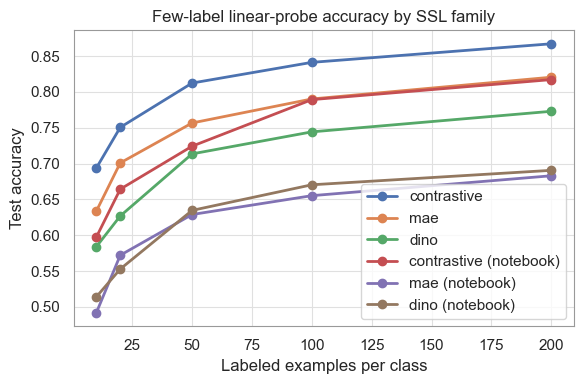

In [10]:
if few_label_results:
    plt.figure(figsize=(6, 4))
    for family, accs in few_label_results.items():
        plt.plot(LABEL_BUDGETS, accs, marker="o", label=family)
    plt.xlabel("Labeled examples per class")
    plt.ylabel("Test accuracy")
    plt.title("Few-label linear-probe accuracy by SSL family")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("No encoders available. See the checkpoint-loading cell above.")

## Summary bar chart: full-label accuracy by family

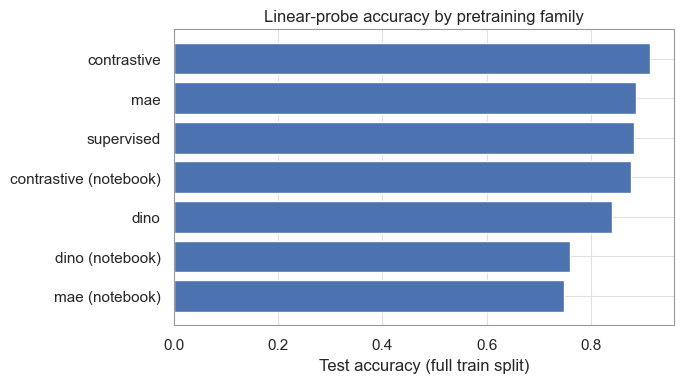

In [11]:
all_results = {family: res["accuracy"] for family, res in linear_probe_results.items()}
all_results["supervised"] = acc_supervised

if all_results:
    families_sorted = sorted(all_results, key=lambda k: all_results[k])
    plt.figure(figsize=(7, 4))
    plt.barh(families_sorted, [all_results[f] for f in families_sorted])
    plt.xlabel("Test accuracy (full train split)")
    plt.title("Linear-probe accuracy by pretraining family")
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("No results available. See the checkpoint-loading cell above.")

## Confusion matrices

Aggregate accuracy hides *which* classes each family confuses. We plot a confusion matrix per
available SSL encoder on the full-label linear probe.

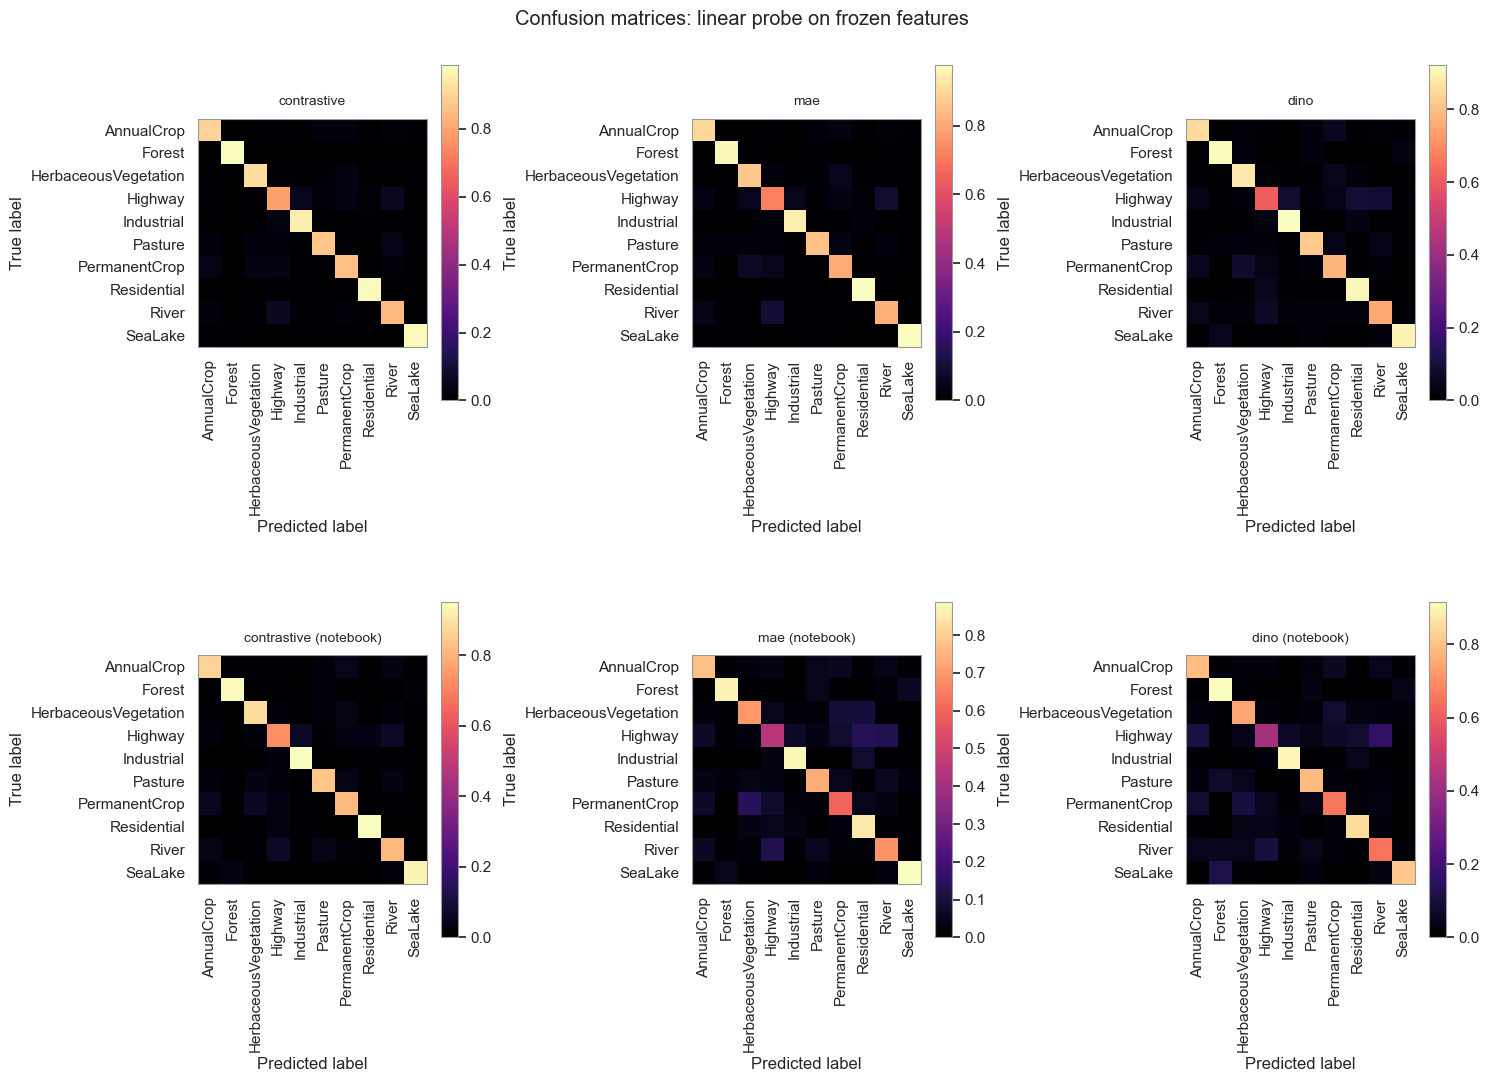

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

# 3x3 grid so all six confusion matrices (and the three spare cells for future SSL families
# or checkpoint sessions) sit close together for easy side-by-side comparison, instead of one
# full-size figure per family.
n_families = len(linear_probe_results)
n_cols = 3
n_rows = math.ceil(n_families / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, (family, res) in zip(axes, linear_probe_results.items()):
    # sklearn's default confusion-matrix template: ConfusionMatrixDisplay draws the matrix and
    # colorbar for us. "magma" is the classic purple-to-pink perceptually-uniform colormap;
    # ax.grid(False) drops the white grid matplotlib's default style would otherwise draw over
    # the cells. include_values=False drops the per-cell numeric annotations -- at this many
    # small subplots and 10 EuroSAT classes, the digits overlap illegibly; the colorbar still
    # conveys the value.
    ConfusionMatrixDisplay.from_predictions(
        features[family]["test_labels"], res["preds"],
        display_labels=EUROSAT_CLASSES, normalize="true",
        cmap="magma", xticks_rotation=90, include_values=False, colorbar=True, ax=ax,
    )
    ax.grid(False)
    # A few points of top padding so this row's title clears the x tick labels rotated up
    # from the row above -- without it "Predicted" and the rotated class names collide with
    # the next row's title.
    ax.set_title(family, fontsize=10, pad=10)

# Hide any unused axes (six families into a 3x3 grid leaves three empty cells).
for ax in axes[n_families:]:
    ax.set_visible(False)

fig.suptitle("Confusion matrices: linear probe on frozen features")
# Extra vertical spacing between rows (hspace) on top of tight_layout, since the rotated
# x-axis tick labels of one row otherwise run into the title of the row below it.
plt.tight_layout()
fig.subplots_adjust(hspace=0.6, top=0.93)
plt.show()
plt.close()

## Attention Maps

Finally, we visualize the attention maps of each encoder on a few test images, to see what contrastive, MAE and DINO presents different attention patterns. This is not a quantitative evaluation, but it can be useful to understand what each encoder focuses on.
This pattern can be related to waht each SSL objective is trying to learn, and can help to understand the differences in performance between the three methods. And how selecting the right SSL objective can be important for a specific task. (Always take into account the downstream task and the data characteristics when selecting a SSL objective.)

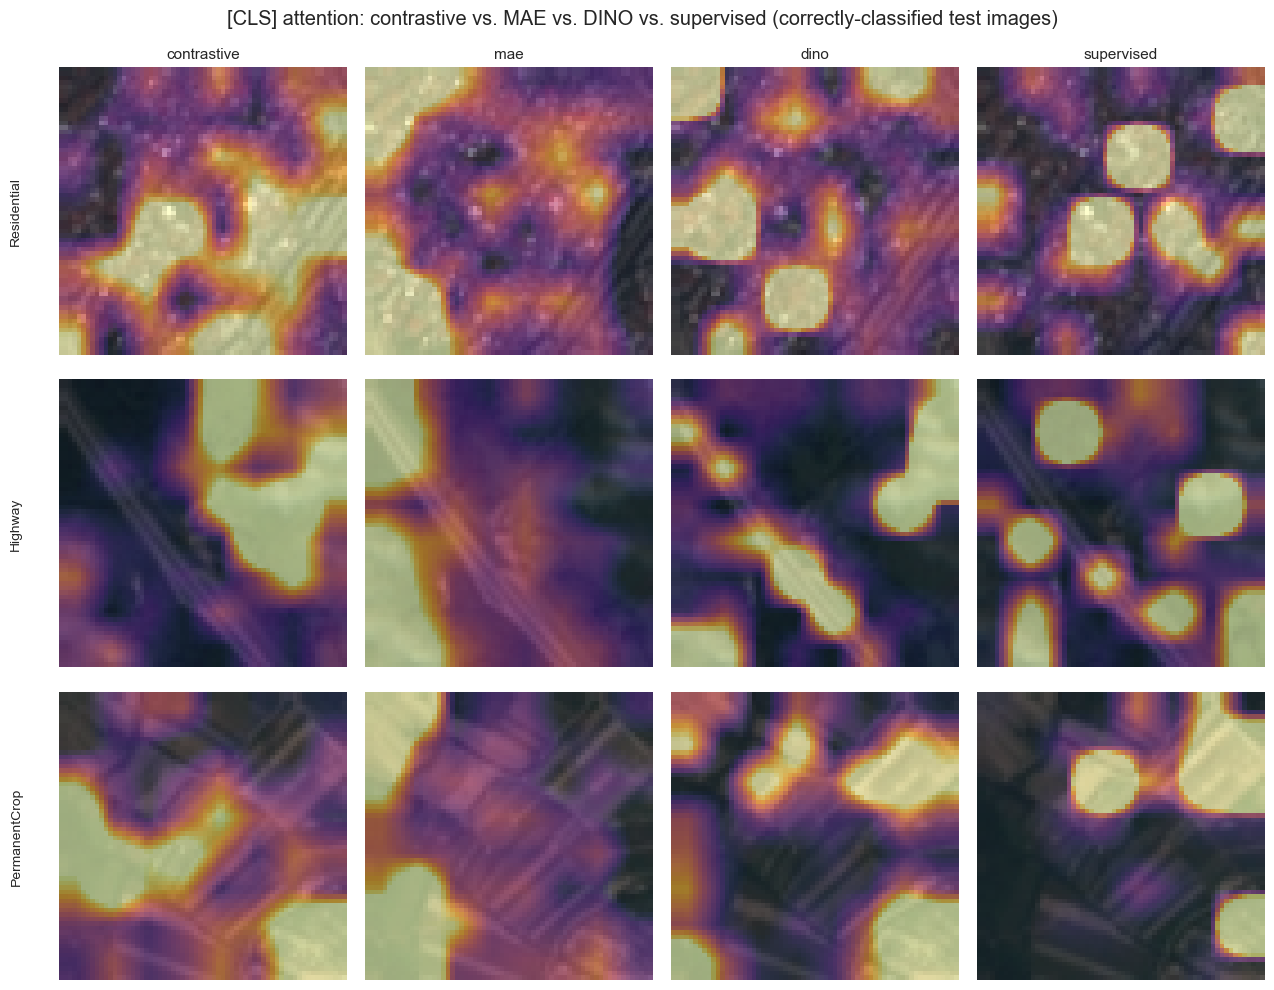

In [13]:
# Attention maps for the four "best-effort" models: the three offline SSL encoders (longer
# pretraining budget: 20,000 steps on SeCo) plus the end-to-end supervised baseline -- not the
# short 400-step notebook checkpoints, since the point here is what each objective converges
# to given a real budget, not the compute-budget comparison from the cells above.
ATTENTION_MODELS = {
    "contrastive": encoders["contrastive"],
    "mae": encoders["mae"],
    "dino": encoders["dino"],
    "supervised": supervised_encoder,
}

# One image per showcase class, drawn from the test split. We only want images that every
# model actually gets right: a misclassified image's attention map is confounded by whatever
# confused that particular model, which would make the four columns harder to compare on
# equal footing. For the three SSL encoders "correct" means the linear-probe prediction
# already computed above (features[...]["test_labels"] / linear_probe_results[...]["preds"]
# share the same order as test_idx). train_supervised_baseline's classification head was
# local to that function and is gone, so for the supervised encoder we instead fit a quick
# linear probe on its own frozen features, purely to get a comparable correct/incorrect
# signal for picking showcase images.
SHOWCASE = ["Residential", "Highway", "PermanentCrop"]

eval_transform = build_eval_transform(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
eval_dataset = load_eurosat(DATASET_PATH, transform=eval_transform)

sup_train_feats, sup_train_labels = prepare_data_features(supervised_encoder, train_subset, pool="cls")
sup_test_feats, sup_test_labels = prepare_data_features(supervised_encoder, test_subset, pool="cls")
_, _, sup_preds = linear_probe_accuracy(sup_train_feats, sup_train_labels, sup_test_feats, sup_test_labels)

correct_by_model = {
    "contrastive": linear_probe_results["contrastive"]["preds"] == features["contrastive"]["test_labels"],
    "mae": linear_probe_results["mae"]["preds"] == features["mae"]["test_labels"],
    "dino": linear_probe_results["dino"]["preds"] == features["dino"]["test_labels"],
    "supervised": sup_preds == sup_test_labels,
}
all_correct = np.logical_and.reduce(list(correct_by_model.values()))

test_targets = np.array(eval_dataset.targets)[test_idx]
picked = {}
for name in SHOWCASE:
    label = EUROSAT_CLASSES.index(name)
    candidates = np.where((test_targets == label) & all_correct)[0]
    if len(candidates) == 0:
        # Fall back to the image with the most model agreement (rare: the four models don't
        # always all agree on the same image).
        agreement = sum(correct_by_model[m].astype(int) for m in correct_by_model)
        candidates = np.where(test_targets == label)[0]
        candidates = candidates[np.argsort(-agreement[candidates])]
    picked[name] = int(test_idx[candidates[0]])

# 3 rows (one per showcase image) x 4 columns (one per model), image + attention overlay
# blended into a single panel per cell so the grid stays compact.
fig, axes = plt.subplots(len(SHOWCASE), len(ATTENTION_MODELS),
                         figsize=(3.2 * len(ATTENTION_MODELS), 3.4 * len(SHOWCASE)))

for row, name in enumerate(SHOWCASE):
    img, label = eval_dataset[picked[name]]
    img_vis = denormalize(img, EUROSAT_MEAN, EUROSAT_STD).permute(1, 2, 0).numpy()
    for col, (model_name, encoder) in enumerate(ATTENTION_MODELS.items()):
        ax = axes[row][col]
        attn = cls_attention_map(encoder, img, head="mean", device=device)
        attn_t = torch.tensor(attn, dtype=torch.float32)[None, None]
        attn_up = torch.nn.functional.interpolate(
            attn_t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0].numpy()
        lo, hi = np.percentile(attn_up, [5, 85])
        attn_stretched = np.clip((attn_up - lo) / max(hi - lo, 1e-8), 0, 1)

        ax.imshow(img_vis)
        ax.imshow(attn_stretched, cmap="inferno", alpha=0.55, vmin=0.0, vmax=1.0)
        ax.axis("off")
        if row == 0:
            ax.set_title(model_name, fontsize=11)
        if col == 0:
            ax.text(-0.15, 0.5, name, fontsize=10, rotation=90,
                    va="center", ha="center", transform=ax.transAxes)

fig.suptitle("[CLS] attention: contrastive vs. MAE vs. DINO vs. supervised "
            "(correctly-classified test images)")
plt.tight_layout()
plt.show()
plt.close()

## Discussion

<div class="alert alert-info">

**Results from a real run of this notebook** (fixed 80/20 split, seed=42). "offline" is each
mechanism's longer, hosted checkpoint (20,000 steps on SeCo); "notebook" is the short 400-step
run saved by that mechanism's own notebook cell, starting from the same random init:

| readout | contrastive (offline) | mae (offline, mean-pool) | dino (offline) | supervised (end-to-end, 15 ep) |
|---|---|---|---|---|
| full-label linear probe | **0.9139** | 0.8876 | 0.8411 | 0.8830 |

| readout | contrastive (notebook) | mae (notebook) | dino (notebook) |
|---|---|---|---|
| full-label linear probe | 0.8767 | 0.7494 | 0.7596 |

| k labels/class | contrastive (offline) | mae (offline) | dino (offline) | contrastive (nb) | mae (nb) | dino (nb) |
|---|---|---|---|---|---|---|
| 10  | 0.694 | 0.634 | 0.584 | 0.597 | 0.492 | 0.514 |
| 20  | 0.751 | 0.701 | 0.627 | 0.664 | 0.572 | 0.553 |
| 50  | 0.812 | 0.757 | 0.714 | 0.724 | 0.629 | 0.635 |
| 100 | 0.841 | 0.790 | 0.744 | 0.789 | 0.655 | 0.670 |
| 200 | 0.867 | 0.821 | 0.773 | 0.817 | 0.683 | 0.691 |

- **Which family wins, and does the ranking change with fewer labels?** Among the offline
  checkpoints, contrastive wins at every label budget in this run, from `k=10` up to
  full-label -- the ranking does not flip. MAE is the closest competitor and is nearly tied
  with contrastive at full-label (0.888 vs. 0.914) but falls off faster as labels shrink, and
  DINO trails throughout. A family's full-label linear-probe score happened to predict its
  few-label ranking here, but that is not guaranteed in general -- always check both regimes
  rather than assuming one predicts the other.
- **How much does pretraining budget matter, holding the mechanism fixed?** The "offline vs.
  notebook" pair for each mechanism isolates exactly one variable: 20,000 SeCo steps versus
  400 EuroSAT steps from the same random init. The gain from training longer is real for all
  three, but very uneven -- contrastive **+0.037**, DINO **+0.082**, and MAE the most budget-
  hungry by far at **+0.138**. This tracks the few-label table too: at `k=10` the 400-step MAE
  and DINO checkpoints are barely better than each other (0.49 vs. 0.51), while the offline
  checkpoints have already separated (0.63 vs. 0.58). Contrastive is the mechanism that gets
  the most out of a short budget, which matters directly for a tutorial-scale compute budget.
- **How far is linear probing from full fine-tuning (`supervised`)?** The end-to-end
  supervised baseline (0.883, 15 epochs, no SSL pretraining at all) lands *between* the offline
  DINO and MAE linear probes and *below* offline contrastive (0.914). With full labels
  available, a well-tuned from-scratch classifier is a genuinely strong baseline here -- it is
  not true in this experiment that any SSL pretraining beats training with all the labels you
  have. The value of contrastive/MAE pretraining shows up more clearly in the few-label
  columns above, where supervised training from scratch has no equivalent low-label number to
  compare against but would be expected to struggle far more than a frozen, pretrained probe.
- **What do the confusion matrices add beyond the headline number?** All six probes struggle
  on the same visually-similar EuroSAT pairs (e.g. `AnnualCrop` vs. `PermanentCrop` vs.
  `Pasture`), but the offline checkpoints show cleaner diagonals overall than their 400-step
  counterparts -- consistent with the accuracy gap above, and a reminder that a single scalar
  hides *which* classes a given amount of pretraining actually fixes.
- **What do the attention maps add?** Overlaying `[CLS]` attention (contrastive, MAE, DINO)
  and the supervised encoder's own attention on the same three correctly-classified images
  (Residential, Highway, PermanentCrop) makes the mechanisms' differences visible rather than
  just numeric: where one objective's gradient never touches `[CLS]` (MAE) versus where it is
  optimized directly (contrastive, DINO) shows up as a difference in how localized and
  structure-aligned the resulting attention looks, even when the linear-probe accuracies alone
  would not tell you why.
- **Which family for which task?** Linear-probe classification accuracy is only one axis.
  DINO's attention maps (see also Notebook 3 and the grid above) suggest it may transfer
  better to per-pixel tasks like segmentation despite its lower classification-probe score
  here; MAE's reconstruction objective is a natural fit for anomaly detection or change
  detection framed as reconstruction error; contrastive embeddings are a strong default for
  retrieval (nearest-neighbor search in embedding space) and, in this run, for classification
  too.

</div>

This closes the loop from Hour 1's framework: **one shared principle** (learn from data
structure, not labels), **three different mechanisms** for turning that principle into a
concrete pretext task, each instantiated here as running code on the same architecture and
the same remote-sensing dataset -- and now, a shared protocol for comparing what each one
actually learned.

**Looking ahead:** the same three-mechanism skeleton (Segments 3.2-3.4) is reused in Hour 3
for time series data -- same principle, same three mechanisms, a different data geometry.

### References

- Chen, T. et al. (2020). *SimCLR.* ICML.
- He, K. et al. (2022). *MAE.* CVPR.
- Caron, M. et al. (2021). *DINO.* ICCV.
- Helber, P. et al. (2019). *EuroSAT.* IEEE JSTARS.